# <font color= #83eac2 >**02 - Limpieza, EDA y Feature Engineering** </font>

---

### **Importar los paquetes y módulos necesarios a lo largo del notebook.**

In [18]:
# ============ IMPORTS ========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
import bootcampviztools as bt
from data_processing import elimina_columnas_id,elimina_Total_Wait_Time, elimina_Visit_Date

### **Cargar Datos**

In [2]:
df = pd.read_csv('../data/raw/ER Wait Time Dataset.csv')
print(f'Shape: {df.shape}')

Shape: (5000, 19)


## <font color = #84c4da >**1. Inspección Inicial** </font>

### **Mostrando la información básica del dataset (Tipos y nulos)**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Visit ID                            5000 non-null   str  
 1   Patient ID                          5000 non-null   str  
 2   Hospital ID                         5000 non-null   str  
 3   Hospital Name                       5000 non-null   str  
 4   Region                              5000 non-null   str  
 5   Visit Date                          5000 non-null   str  
 6   Day of Week                         5000 non-null   str  
 7   Season                              5000 non-null   str  
 8   Time of Day                         5000 non-null   str  
 9   Urgency Level                       5000 non-null   str  
 10  Nurse-to-Patient Ratio              5000 non-null   int64
 11  Specialist Availability             5000 non-null   int64
 12  Facility Size (Be

### **Verificando las variables númericas**

In [4]:
df.describe()

,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Satisfaction
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.238200,3.875000,87.118800,11.704200,24.827000,45.385400,81.916600,2.771600
std,1.200895,3.043292,57.998585,10.437284,24.807994,35.619975,68.084538,1.424584
min,1.000000,0.000000,10.000000,0.000000,1.000000,2.000000,4.000000,1.000000
25%,3.000000,1.000000,36.000000,3.000000,6.000000,17.000000,27.000000,1.000000
50%,3.000000,3.000000,74.000000,8.000000,16.000000,35.000000,60.000000,3.000000
75%,4.000000,6.000000,138.000000,18.000000,36.000000,66.000000,122.000000,4.000000
max,5.000000,10.000000,200.000000,66.000000,163.000000,233.000000,442.000000,5.000000


### **Mostrando las primeras filas**

In [5]:
df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


### **Verificando valores Nulos**

In [6]:
df.isnull().all()

Visit ID                              False
Patient ID                            False
Hospital ID                           False
Hospital Name                         False
Region                                False
Visit Date                            False
Day of Week                           False
Season                                False
Time of Day                           False
Urgency Level                         False
Nurse-to-Patient Ratio                False
Specialist Availability               False
Facility Size (Beds)                  False
Time to Registration (min)            False
Time to Triage (min)                  False
Time to Medical Professional (min)    False
Total Wait Time (min)                 False
Patient Outcome                       False
Patient Satisfaction                  False
dtype: bool

<font color= #e19a94>***Se confirma que no hay nulos***</font>


### **Verificación de duplicados**


In [7]:
print(f'Filas duplicadas: {df.duplicated().sum()}')

Filas duplicadas: 0


<font color= #e19a94>***Se confirma que no hay duplicados***</font>

## <font color = #84c4da >**2. División Train y Test** </font>

---

In [8]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size= 0.2, random_state= 42)
print(f'Train: {train_set.shape}')
print(f'Test : {test_set.shape}')

Train: (4000, 19)
Test : (1000, 19)


### **2.1 Guardando train y test**

In [9]:
# Guarda los split sin agregar columna extra

train_set.to_csv('../data/train/train.csv', index = False)
test_set.to_csv('../data/test/test.csv', index = False)

## <font color = #84c4da >**3. Limpieza** </font>

---

### **3.1 Eliminación de columnas no útiles**

**Verificando los valores de `Hospital Name`, observa que no son únicos y se mantienen.**

In [10]:
train_set['Hospital Name'].value_counts()

Hospital Name
Riverside Medical Center        828
Northside Community Hospital    803
Summit Health Center            792
Springfield General Hospital    790
St. Mary’s Regional Health      787
Name: count, dtype: int64

<font color= #e19a94>***Eliminando los identificadores (`Visit ID`, `Patient ID`, `Hospital ID`) ya que no aportan información al modelo.***</font>

In [11]:
train_set = elimina_columnas_id(train_set)

In [12]:
train_set.head()

,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
4227,Northside Community Hospital,Rural,2024-03-05 17:02:37,Tuesday,Spring,Afternoon,Low,4,1,42,14,37,86,137,Discharged,1
4676,Summit Health Center,Urban,2024-01-29 19:01:28,Monday,Winter,Evening,Medium,4,9,86,15,31,143,189,Discharged,1
800,Northside Community Hospital,Rural,2024-03-13 02:01:35,Wednesday,Spring,Afternoon,Medium,4,0,40,22,36,44,102,Discharged,2
3671,Summit Health Center,Urban,2024-03-15 20:50:07,Friday,Spring,Afternoon,Low,5,1,112,22,52,61,135,Discharged,1
4193,Springfield General Hospital,Urban,2024-11-28 00:03:51,Thursday,Fall,Afternoon,Low,5,10,61,23,45,87,155,Discharged,1


**Verificando `Total Wait Time` = `Time to Registration (min)` + `Time to Triage (min)`+ `Time to Medical Professional (min)`**

In [13]:
coinciden = (train_set['Time to Registration (min)'] + 	
             train_set['Time to Triage (min)'] +
             train_set['Time to Medical Professional (min)'] == train_set['Total Wait Time (min)']).all()

print(f'¿ Todas las filas Coinciden? : {coinciden}')

¿ Todas las filas Coinciden? : True


<font color= #e19a94>***Eliminando `Total Wait Time` = Time to Registration (min) + Time to Triage (min) + Time to Medical Professional (min)***</font>

In [14]:
train_set = elimina_Total_Wait_Time(train_set)

In [15]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 4000 entries, 4227 to 860
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Hospital Name                       4000 non-null   str  
 1   Region                              4000 non-null   str  
 2   Visit Date                          4000 non-null   str  
 3   Day of Week                         4000 non-null   str  
 4   Season                              4000 non-null   str  
 5   Time of Day                         4000 non-null   str  
 6   Urgency Level                       4000 non-null   str  
 7   Nurse-to-Patient Ratio              4000 non-null   int64
 8   Specialist Availability             4000 non-null   int64
 9   Facility Size (Beds)                4000 non-null   int64
 10  Time to Registration (min)          4000 non-null   int64
 11  Time to Triage (min)                4000 non-null   int64
 12  Time to Medical Prof

<font color= #e19a94>***Eliminando `Visit Date` columna innecesaria porque `Day of Week`,`Season`,`Time of Day` tiene la misma información***</font>

In [16]:
train_set = elimina_Visit_Date(train_set)

In [17]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 4000 entries, 4227 to 860
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Hospital Name                       4000 non-null   str  
 1   Region                              4000 non-null   str  
 2   Day of Week                         4000 non-null   str  
 3   Season                              4000 non-null   str  
 4   Time of Day                         4000 non-null   str  
 5   Urgency Level                       4000 non-null   str  
 6   Nurse-to-Patient Ratio              4000 non-null   int64
 7   Specialist Availability             4000 non-null   int64
 8   Facility Size (Beds)                4000 non-null   int64
 9   Time to Registration (min)          4000 non-null   int64
 10  Time to Triage (min)                4000 non-null   int64
 11  Time to Medical Professional (min)  4000 non-null   int64
 12  Patient Outcome     

## <font color = #84c4da >**4. Mini EDA** </font>

---

### **4.1 Analiza la distribución frecuencial del Target**

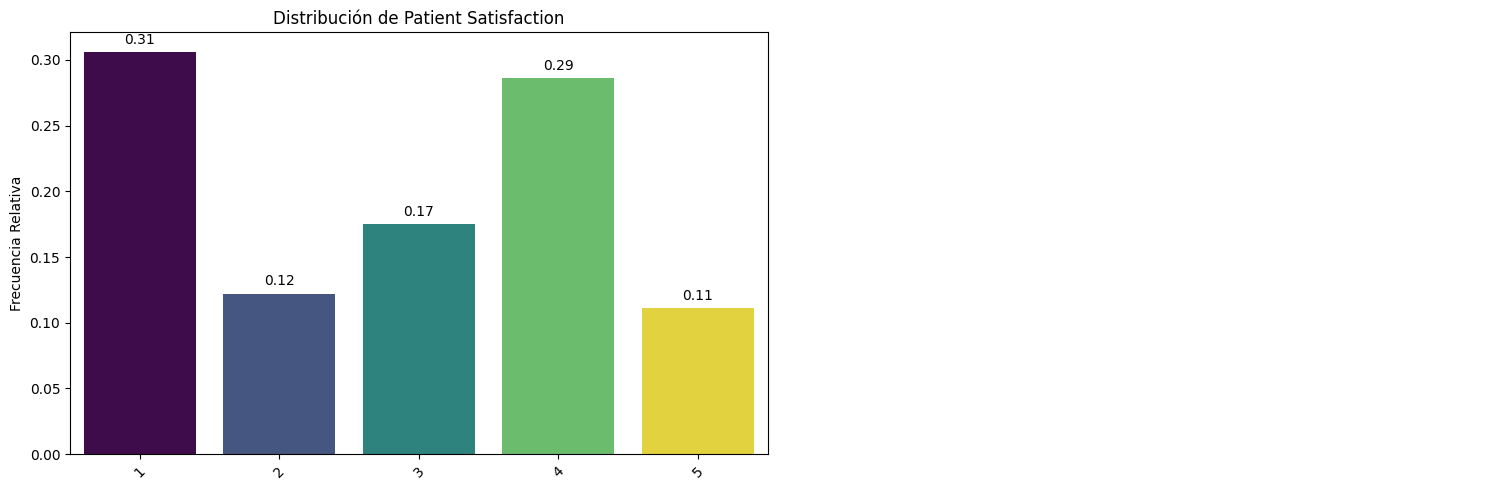

In [19]:
target = 'Patient Satisfaction'
bt.pinta_distribucion_categoricas(train_set,[target], mostrar_valores= True, relativa= True)